hari 0 pagi: nasipadang
hari 0 malam: capcay
hari 1 pagi: kebab
hari 1 malam: seblak
hari 2 pagi: nasipenyetan
hari 2 malam: nasigoreng
hari 3 pagi: cilok
hari 3 malam: cilok
hari 4 pagi: mieayam
hari 4 malam: roti
hari 5 pagi: nasipadang
hari 5 malam: nasigoreng
hari 6 pagi: nasipadang
hari 6 malam: gorengan
hari 7 pagi: nasipadang
hari 7 malam: mieayam
hari 8 pagi: cilok
hari 8 malam: nasigoreng
hari 9 pagi: warteg
hari 9 malam: warteg
hari 10 pagi: roti
hari 10 malam: nasi telur
hari 11 pagi: nasigoreng
hari 11 malam: nasi telur
hari 12 pagi: seblak
hari 12 malam: kebab
hari 13 pagi: cireng
hari 13 malam: capcay
hari 14 pagi: mi instan
hari 14 malam: cireng
hari 15 pagi: warteg
hari 15 malam: seblak
hari 16 pagi: roti
hari 16 malam: mieayam
hari 17 pagi: tahutek
hari 17 malam: warteg
hari 18 pagi: mieayam
hari 18 malam: bakso
hari 19 pagi: nasigoreng
hari 19 malam: roti
hari 20 pagi: nasipenyetan
hari 20 malam: roti
hari 21 pagi: cireng
hari 21 malam: ayamgeprek
hari 22 pagi: nasigo

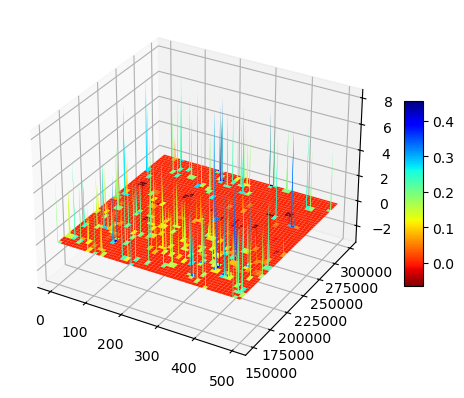

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NPM = 24083010033

makan =  pd.read_csv("C:/Users/LENOVO/.ipython/makanan_1.csv")
budget= 1e6 #rupiah

wkenyang_base= 0.8
wrasa_base= 0.7
wsehat_base= 0.9 # simpangan lebih besar
wbosan_base= 0.2

skor_kumulatif= 0.0
SAMPLE_NUM= 500

sampleid= np.arange(0, 500)
# skor perorangan
skor= np.zeros(SAMPLE_NUM, dtype=np.double)
sisa= np.zeros(SAMPLE_NUM, dtype=np.double)
sehat= np.zeros(SAMPLE_NUM, dtype=np.double)
pilihankum= np.zeros(SAMPLE_NUM, dtype=np.double)

SISA_MININUM= 150e3
SISA_MAKSIMUM= 300e3
bin_sisa= np.arange(SISA_MININUM, SISA_MAKSIMUM, 1000)
resp_sehat= np.zeros((SAMPLE_NUM, len(bin_sisa)), dtype=np.double)
resp_pilih= np.zeros((SAMPLE_NUM, 61), dtype=np.double)

for n in range(0, SAMPLE_NUM):
    budget=1e6
    skor_kumulatif= 0
    skor_sehat= 0
    
    for i in range(0, 31): 
        pilihan= np.random.randint(0, len(makan))
      
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base, scale=0.2)
        skor_kumulatif= skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        if n < 1:  
            print(f"hari {i} pagi: {makan['makanan'][pilihan]}")
        resp_pilih[n][2*1]= pilihan
        
        # makan keduas
        pilihan= np.random.randint(0, len(makan))
    
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base+0.2, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base*2, scale=0.2)
        skor_kumulatif= skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        if n < 1: 
            print(f"hari {i} malam: {makan['makanan'][pilihan]}")  
        resp_pilih[n][2*1+1]= pilihan
    
    sisa[n]= budget
    skor[n]= skor_kumulatif
    sehat[n]= skor_sehat
    if n < 5: 
        print(f"[Simulasi {n}] Skor: {skor_kumulatif:.2f}, Sisa uang: {budget}, Skor sehat: {skor_sehat}")

    resp_sehat[n][ int((budget-SISA_MININUM)/1000)]= skor_sehat

np.corrcoef(skor, sisa)
np.histogram(sisa)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
Y, X = np.meshgrid(bin_sisa, sampleid)
# Colorize the surface using a colormap
surf = ax.plot_surface(X, Y, resp_sehat, 
                       cmap='jet_r',   # try 'plasma', 'coolwarm', etc.
                       edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)


Kode diatas digunakan untuk melakukan simulasi program kebiasaan makan selama sebulan secara acak dengan tujuan untuk melihat apakah terdapat hubungan antara makanan, kesehatan dan uang. Dataset makanan berisi informasi menenai jenis makanan, rasa, kesehatan,tingkat kenyang, tingkat kebosanan dan harga makanan. Pada simulasi ini budget perbulannya adalah satu juta rupiah, dengan makan sebanyak 2 kali perhari. Setelah simulasi selesai dengan menyimpan data sisa uang dan skor kesehatan juga sudah disimpan maka akan divisualisasikan dalam grafik 3D untuk memvisualisasikan hubungan antara simulasi, sisa uang, dan skor kesehatan.

Pada output, dapat dilihat terdapat makanan apa saja yang bisa konsumsi setiap hari untuk dua kali makan. Misal, pada tanggal 31 atau akhir bulan pagi kita makan mie ayam kemudian untuk makan malam bisa makan nasi padang. Setelah itu, visualisasi grafik 3D menunjukkan pola permukaan orange yang rata dengan beberapa lonjakan berwarna terang seperti kuning dan biru. Artinya, sebagian besar menghasilkan sisa uang pada rentang yang mirip dan skor kesehatan cenderung rendah yang dapat dilihat pada permukaan dasar yang didominasi warna orange. Pada sumbu X terdapat rentang 0-500 yang menandakan skenario simulasi ke-n, sumbu Y dengan rentang 150.000-300.000 merupakan sisa uang setelah 31 hari makan, dan sumbu z+ warna merupakan skor kesehatan kumulatif. Permukaan berwarna merah menandakan bahwa terlalu banyak skenario yang menghasilkan skor kesehatan yang rendah, kemudian terdapat beberapa tiang dengan warna kuning, hijau, dan biru yang artinya skenario langka di mana seseorang berhasil mendapatkan skor dengan kesehatan tinggi, dan tiang yang muncul pada sumbu Y artinya orang yang sehat tidak selalu palinghemat. 

In [9]:
# (1) cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat) positif 
idx_sehat_positif = np.where(sehat > 0)[0]
idx_sehat_positif

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  32,  33,  34,  35,  36,  37,  38,  39,  40,
        41,  42,  43,  44,  45,  47,  48,  49,  50,  51,  52,  53,  54,
        55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,
        68,  69,  70,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
        82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  95,  96,
        97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
       110, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
       124, 125, 126, 127, 128, 129, 130, 131, 132, 134, 135, 136, 137,
       138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150,
       151, 152, 153, 154, 155, 157, 158, 159, 160, 161, 162, 163, 164,
       165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177,
       178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 18

Pada source code diatas digunakan untuk mencari semua indeks simulasi yang memiliki skor sehat lebih dari 0, yang artinya makanan selama 31 hari memberi efek kesehatan positif yang kemudian disimpan pada idx_sehat_pos. 

Pada output terdapat dapat dilihat pada ke skenario keberapa hasil indeks positif terlihat, misal di output pada indeks ke-0, ke-1, ke02, ke-4, dst. pada indeks tersbut hasilnya positif. 

In [10]:
# (2) cari titik-titik dengan sisa uang bulanan positif dari (1)
idx_valid = idx_sehat_positif[sisa[idx_sehat_positif] > 0]

print("Total pola makan valid (sehat & sisa uang > 0):", len(idx_valid))

Total pola makan valid (sehat & sisa uang > 0): 470


Kode diatas digunakan untuk mengambil sisa uang positif, terdapat 119 yang sehat setelah itu akan dicek kembali apakah terdapat sisa uang masih positif yang memenuhi syarat yakni sehat positif dan sisa uang positif. Kemudian hasilnya akan disimpan pada idx_valid. 

Pada output diketahui terdapat total pola makan yang valid artinya makanan tersebut sehat dengan sisa uang lebih dari 0 rupiah terdapat 470. 

In [85]:
# (3) cari titik dengan skor skumulatif terbesar (skor) di mana nilai kumulatif kesehatannya positif
if len(idx_valid) > 0:
    best_idx = idx_valid[np.argmax(skor[idx_valid])]
    print("Index terbaik:", best_idx)
    print("Skor kumulatif:", skor[best_idx])
    print("Sisa uang:", sisa[best_idx])
    print("Skor sehat:", sehat[best_idx])

Index terbaik: 263
Skor kumulatif: 107.96345517946504
Sisa uang: 83000.0
Skor sehat: 10.500000000000004


Source code diatas digunakan untuk mencari titik dengan skor kumuliatif terbesar yang dimana nilai kumulatifnya menghasilkan kesehatan yang psoitif. Kode diatas mengambil idx_sehat_pos yang kemudian dicari skor kumulatif terbesarnya. Pada output, terdapat indeks terbaik yakni pada angka 263 yang artinya dari 500 simulasi makanan, simulasi ke-263 yang paling terbaik dan sesuai kriteria yakni memiliki skot kumulatif terbesar dengan skor sehat positif. Skor kumulatif padaangka 107.96 memiliki arti total kepuasan dari seluru keputusan makan dalam sebulan. Untuk sisa uang dengan makan 2 kali sehari adalah Rp. 83.000 dan skor sehat adalah 10,5 yang artinya dari segi kesehatan, pola makan pada simulasi ini baik karena nilai positif cukup tinggi dibandingkan rata-rata simualsi lain yang negatif. 

In [1]:
# (4) tampikan jadwal makanan sesuai pilihan (resp_pilih)
sampleid= np.arange(0, 500)
# skor perorangan
skor= np.zeros(SAMPLE_NUM, dtype=np.double)
sisa= np.zeros(SAMPLE_NUM, dtype=np.double)
sehat= np.zeros(SAMPLE_NUM, dtype=np.double)
pilihankum= np.zeros(SAMPLE_NUM, dtype=np.double)

SISA_MININUM= 150e3
SISA_MAKSIMUM= 300e3
bin_sisa= np.arange(SISA_MININUM, SISA_MAKSIMUM, 1000)
resp_sehat= np.zeros((SAMPLE_NUM, len(bin_sisa)), dtype=np.double)
resp_pilih= np.zeros((SAMPLE_NUM, 61), dtype=np.double)

for n in range(0, SAMPLE_NUM):
    budget=1e6
    skor_kumulatif= 0
    skor_sehat= 0
    
    for i in range(0, 31): 
        pilihan= np.random.randint(0, len(makan))
      
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base, scale=0.2)
        skor_kumulatif= skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        if n == 0: 
            print(f"hari {i} pagi: {makan['makanan'][pilihan]}")  
        resp_pilih[n][2*1]= pilihan
        
        # makan keduas
        pilihan= np.random.randint(0, len(makan))
    
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base+0.2, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base*2, scale=0.2)
        skor_kumulatif= skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        if n == 0: 
            print(f"hari {i} malam: {makan['makanan'][pilihan]}")   
        resp_pilih[n][2*1+1]= pilihan

NameError: name 'np' is not defined

Kode ini digunakan untuk membuat program menyusun jaadwal makanan lengkap selama 31 hari dari hasil terbaik. Jadwal ini berisi makanan acak tapi sesuai dengan hasil simulasi skor kumulatif tertinggi. Pada jadwal ini mencerminkan pola strategi makan paling memuaskan dari sisi skor gabungan natara kenyang, rasa, sehat, dan bosan. Namun, dari analisis sebelumnya terjadi pengeluaran yang melebihi budget jika menyesuaikan dengan jadwal yang sehat dan positif ini. 